In [89]:
import numpy as np
import matplotlib.pyplot as plt

In [90]:
def is_stable(pattern_to_test, weight_matrix):
    state = pattern_to_test.copy()
    signals = weight_matrix @ state
    new_state = np.where(signals >= 0,1,-1)
    return np.array_equal(new_state, state)

In [91]:
def est_basin(current_pattern, weight_matrix):
    rng = np.random.default_rng()
    perm = rng.permutation(100) #part a
    
    for i in range(1,51): #part b
        p_copy = current_pattern.copy()#part b.i
        index_flip = perm[:i]
        p_copy[index_flip] *= -1 #part b.ii
        
        for x in range(10): #part b.iii
            h = weight_matrix @ p_copy
            p_copy = np.where(h>= 0,1,-1)
        if not np.array_equal(p_copy, current_pattern):#part b.iv
            return i #part c
    return 50

In [92]:
n = int(input("Bipolar Vector Size (default 100): ") or 100) 
num_p = int(input("Number of Patters (default 50): ") or 50)
num_runs = int(input("Number of Experimental runs (defualt 5): ") or 5)

In [93]:
def hopfield(num_runs, n, num_p):
    final_stables = []
    final_unstable_pers = []
    basin_figs = []
    basin_array = []
    for i in range(num_runs):
        #n = 100
        #num_p = 50

        bipolar_arrays = np.random.choice([-1, 1], size=(num_p, n))

        sum_matrix = np.zeros((n,n))
        stable_counts = []
        stable_percentages = []
        unstable_counts = []
        unstable_percentages = []
        basin_histograms = np.zeros((num_p, 51))
        for p in range(num_p):
            current_p = bipolar_arrays[p]
            sum_matrix += np.outer(current_p, current_p) 
            weights = sum_matrix / n
            np.fill_diagonal(weights, 0)
            
            stable_count = 0
            unstable_count = 0
            for j in range(p+1):
                if is_stable(bipolar_arrays[j], weights):
                    stable_count += 1
                    basin_size = est_basin(bipolar_arrays[j], weights)
                    
                else:
                    unstable_count+=1
                    basin_size = 0
                basin_histograms[p][basin_size]+=1
            fraction_stable = stable_count / (p+1)
            stable_counts.append(stable_count)
            stable_percentages.append((fraction_stable))
            unstable_counts.append(unstable_count)
            unstable_percentages.append(1-(fraction_stable))
        fig = plt.figure(figsize=(12, 8))
        x_basin_sizes = np.arange(51)


        even_ps = range(2, 51, 2)
        colors = plt.cm.cool(np.linspace(0, 1, len(even_ps)))
        markers = ['o', '*', 'v', 'x', '^', 'D']
        for k, p in enumerate(even_ps):
            p_idx = p - 1  
            counts = basin_histograms[p_idx]
            total_patterns_tested = np.sum(counts)
            if total_patterns_tested > 0:
                fractions = counts / total_patterns_tested
            else:
                fractions = np.zeros_like(counts)
            plt.plot(x_basin_sizes, fractions, color=colors[k], marker=markers[k % len(markers)], markersize=5,linewidth=1.5,label=f'p = {p}')

        plt.xlabel('Basin Size')
        plt.ylabel('Fraction of Imprinted Patterns With Equal Basin Size')
        plt.title(f'Fraction of Imprinted Patterns With a Basin Size for Different Basin Sizes Experiment {i+1}')
        plt.grid(alpha=0.3)
        plt.legend( loc='upper right', ncol=5)
        plt.tight_layout()
        #plt.show()
        basin_figs.append(fig)
        final_stables.append(stable_counts)
        final_unstable_pers.append(unstable_percentages)
        basin_array.append(basin_histograms)
        
    return np.array(final_stables), np.array(final_unstable_pers), basin_figs

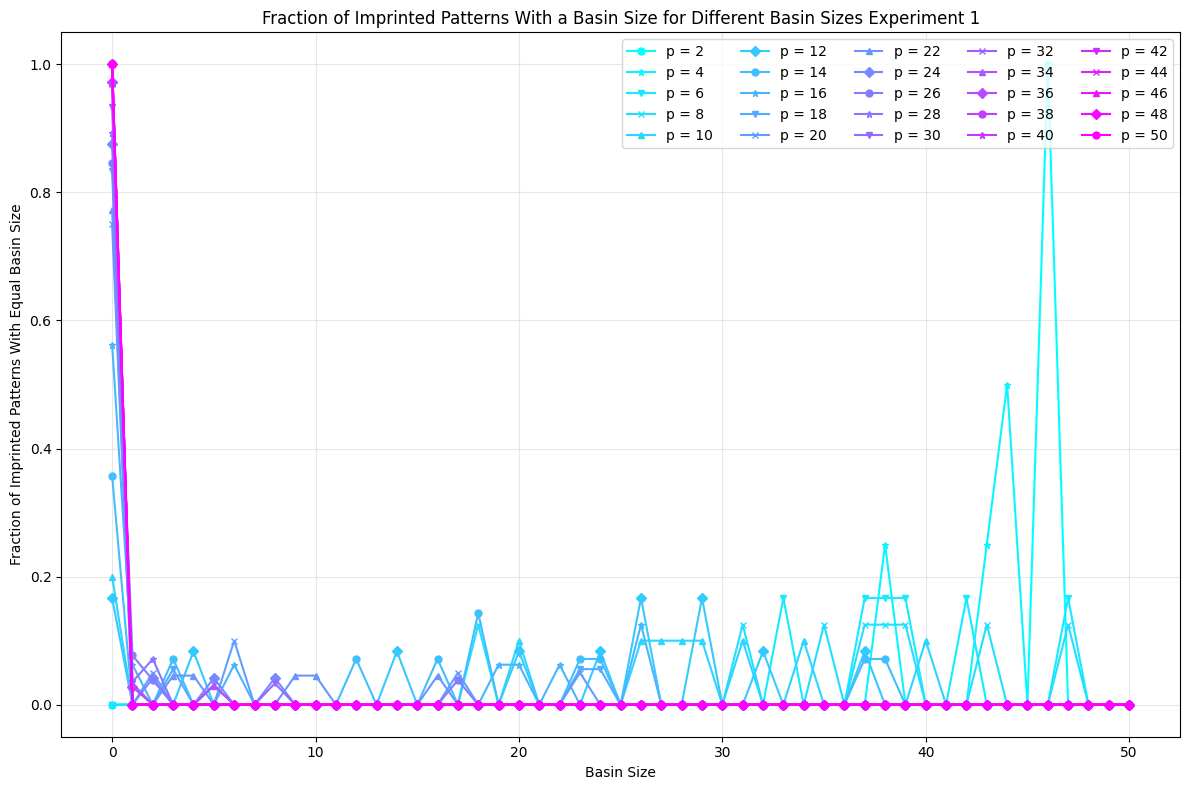

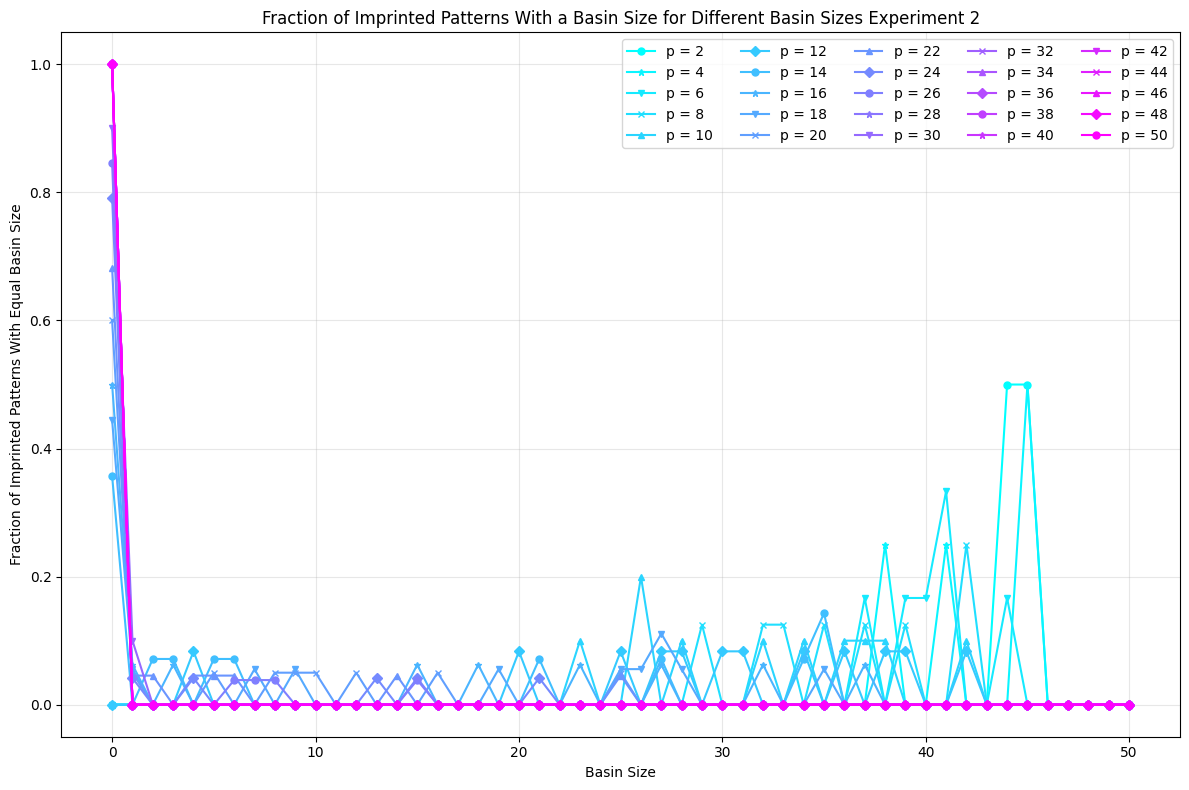

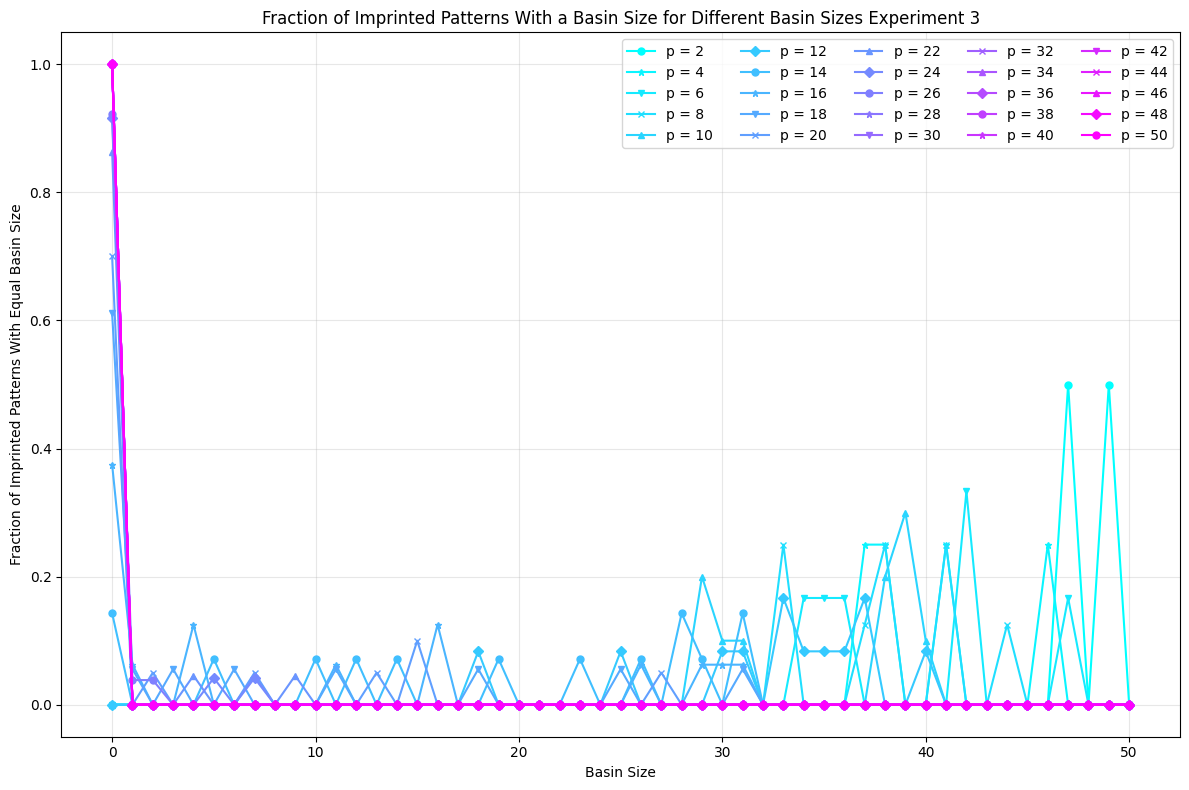

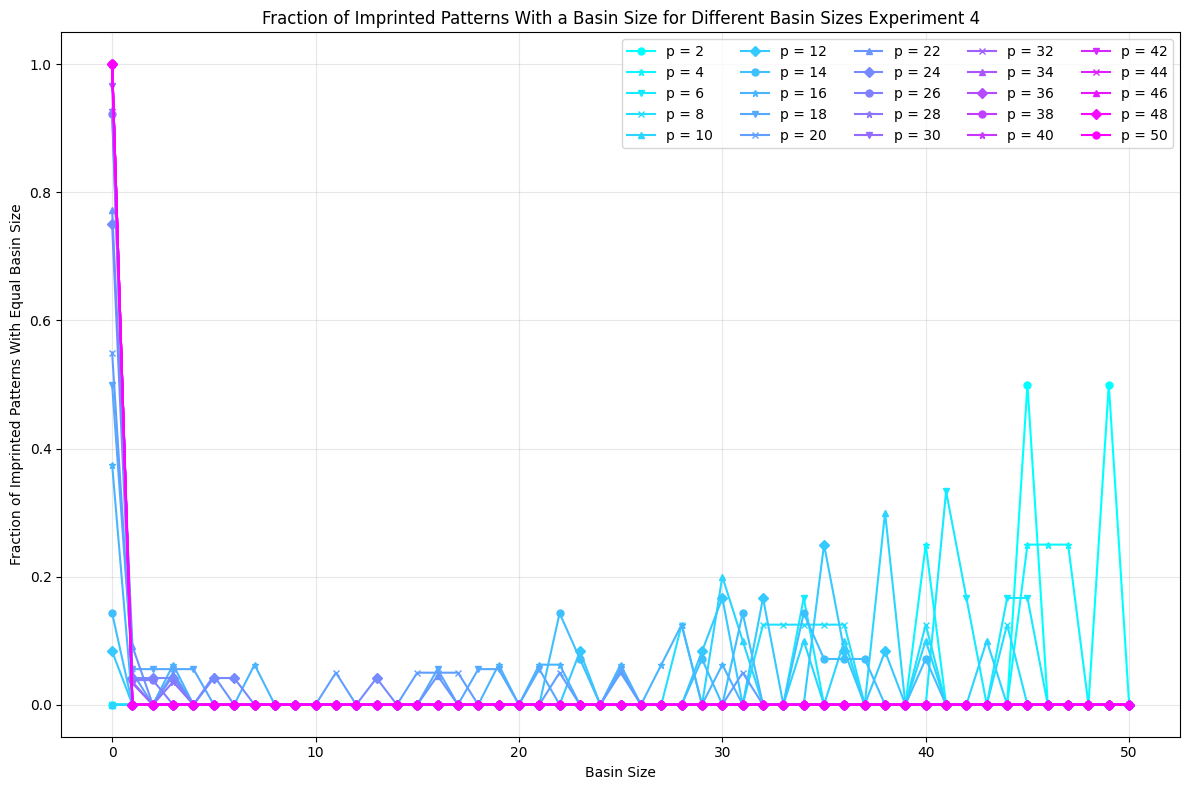

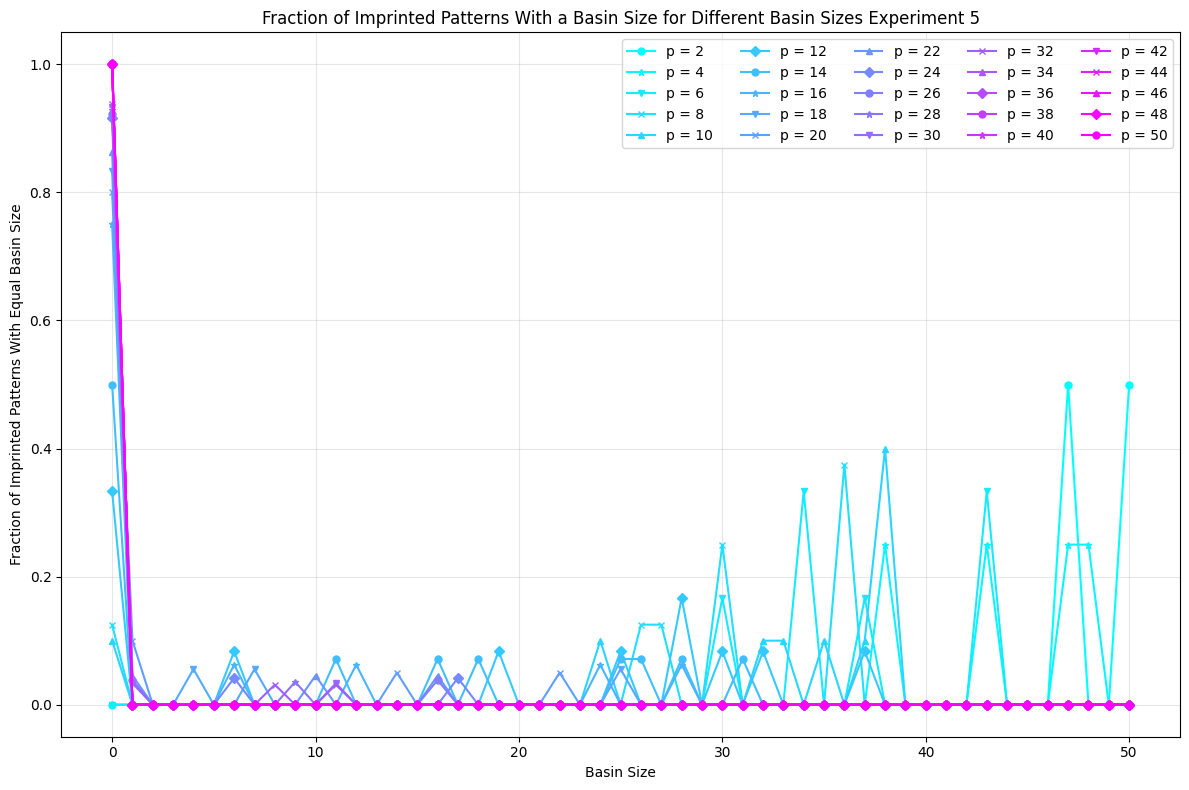

In [94]:
stables, unstables, basin_histograms = hopfield(num_runs, n, num_p) 
unstable_avg = np.mean(unstables, axis=0)
unstable_std = np.std(unstables, axis=0)
unstable_upper = unstable_avg+unstable_std
unstable_lower = unstable_avg-unstable_std


stable_avg = np.mean(stables, axis=0)
stable_std = np.std(unstables, axis=0)
stable_upper = stable_avg+stable_std
stable_lower = stable_avg-stable_std


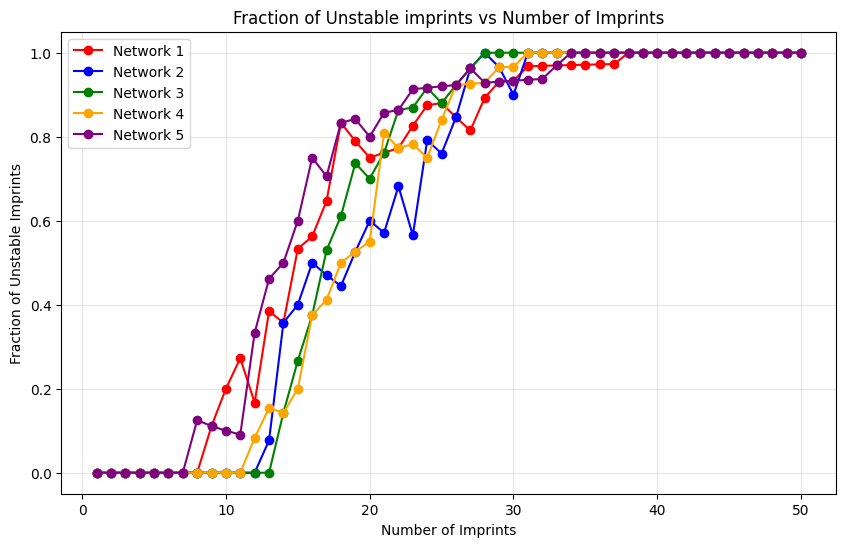

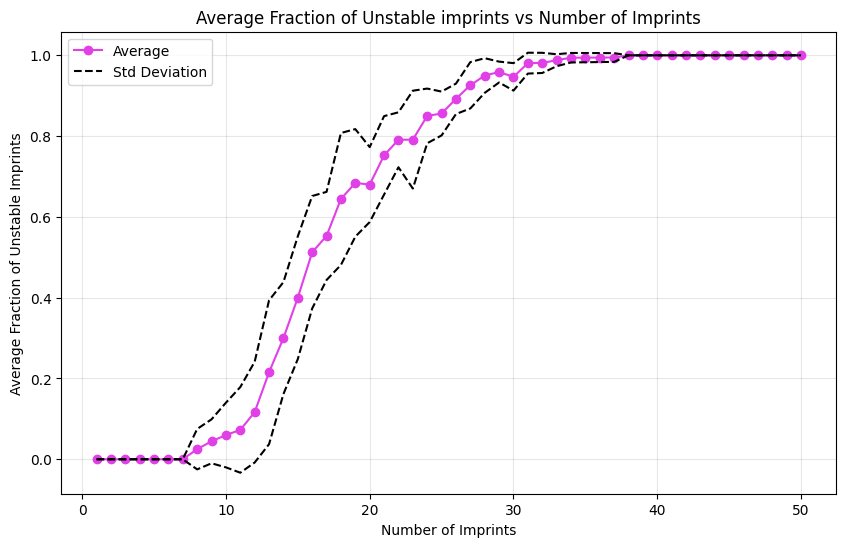

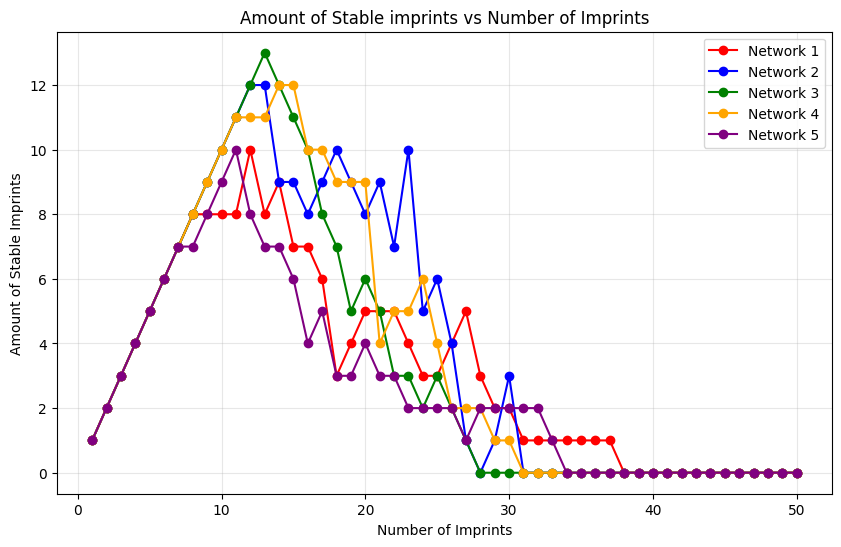

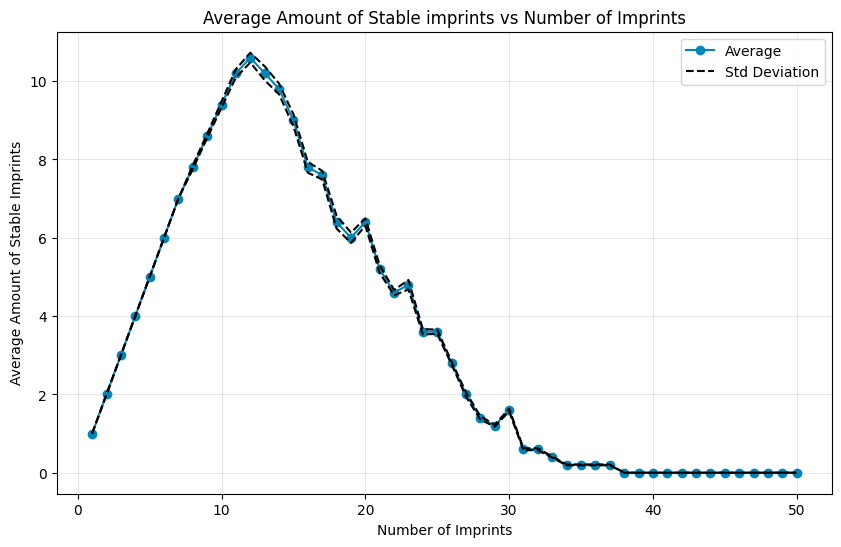

In [95]:
x = np.arange(1, 51)
colors=['red','blue','green','orange','purple']
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(x, unstables[i],c=colors[i],marker='o',label=f'Network {i+1}')
plt.xlabel('Number of Imprints')
plt.ylabel('Fraction of Unstable Imprints')
plt.title('Fraction of Unstable imprints vs Number of Imprints')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(x, unstable_avg,c="#e040e6",marker='o',label=f'Average')
plt.plot(x, unstable_upper, color='black', linestyle='--', label='Std Deviation')
plt.plot(x, unstable_lower, color='black', linestyle='--')
plt.xlabel('Number of Imprints')
plt.ylabel('Average Fraction of Unstable Imprints')
plt.title('Average Fraction of Unstable imprints vs Number of Imprints')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(x, stables[i],c=colors[i],marker='o',label=f'Network {i+1}')
plt.xlabel('Number of Imprints')
plt.ylabel('Amount of Stable Imprints')
plt.title('Amount of Stable imprints vs Number of Imprints')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x, stable_avg,c="#0386b6",marker='o',label=f'Average')
plt.plot(x, stable_upper, color='black', linestyle='--', label='Std Deviation')
plt.plot(x, stable_lower, color='black', linestyle='--')
plt.xlabel('Number of Imprints')
plt.ylabel('Average Amount of Stable Imprints')
plt.title('Average Amount of Stable imprints vs Number of Imprints')
plt.grid(alpha=0.3)
plt.legend()
plt.show()



In [96]:
"""

plt.figure(figsize=(12, 8))
x_basin_sizes = np.arange(51)


even_ps = range(2, 51, 2)
colors = plt.cm.cool(np.linspace(0, 1, len(even_ps)))
markers = ['o', '*', 'v', 'x', '^', 'D']
for i, p in enumerate(even_ps):
    p_idx = p - 1  
    counts = basin_histograms[p_idx]
    total_patterns_tested = np.sum(counts)
    if total_patterns_tested > 0:
        fractions = counts / total_patterns_tested
    else:
        fractions = np.zeros_like(counts)
    plt.plot(x_basin_sizes, fractions, color=colors[i], marker=markers[i % len(markers)], markersize=5,linewidth=1.5,label=f'p = {p}')

plt.xlabel('Basin Size')
plt.ylabel('Fraction of Imprinted Patterns With Equal Basin Size')
plt.title('Fraction of Imprinted Patterns With a Basin Size for Different Basin Sizes')
plt.grid(alpha=0.3)
plt.legend( loc='upper right', ncol=5)
plt.tight_layout()
plt.show()
"""

"\n\nplt.figure(figsize=(12, 8))\nx_basin_sizes = np.arange(51)\n\n\neven_ps = range(2, 51, 2)\ncolors = plt.cm.cool(np.linspace(0, 1, len(even_ps)))\nmarkers = ['o', '*', 'v', 'x', '^', 'D']\nfor i, p in enumerate(even_ps):\n    p_idx = p - 1  \n    counts = basin_histograms[p_idx]\n    total_patterns_tested = np.sum(counts)\n    if total_patterns_tested > 0:\n        fractions = counts / total_patterns_tested\n    else:\n        fractions = np.zeros_like(counts)\n    plt.plot(x_basin_sizes, fractions, color=colors[i], marker=markers[i % len(markers)], markersize=5,linewidth=1.5,label=f'p = {p}')\n\nplt.xlabel('Basin Size')\nplt.ylabel('Fraction of Imprinted Patterns With Equal Basin Size')\nplt.title('Fraction of Imprinted Patterns With a Basin Size for Different Basin Sizes')\nplt.grid(alpha=0.3)\nplt.legend( loc='upper right', ncol=5)\nplt.tight_layout()\nplt.show()\n"

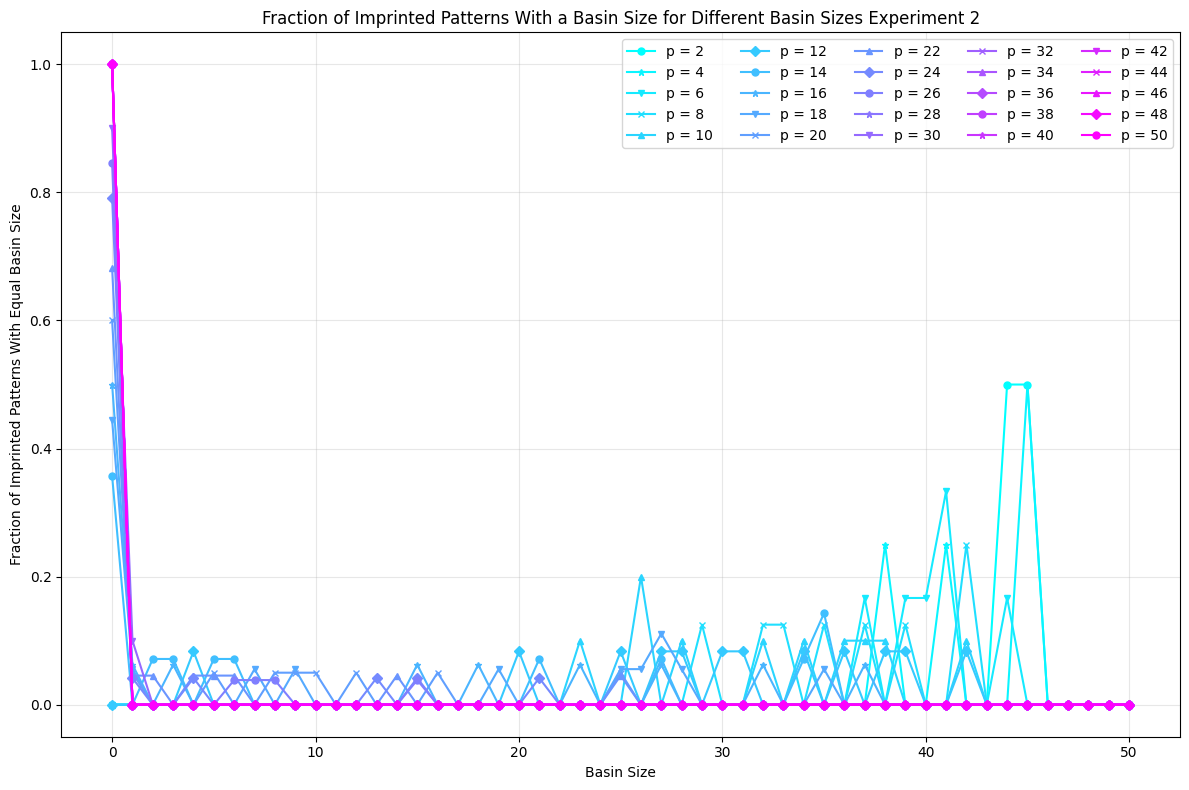

In [ ]:
basin_histograms[0]

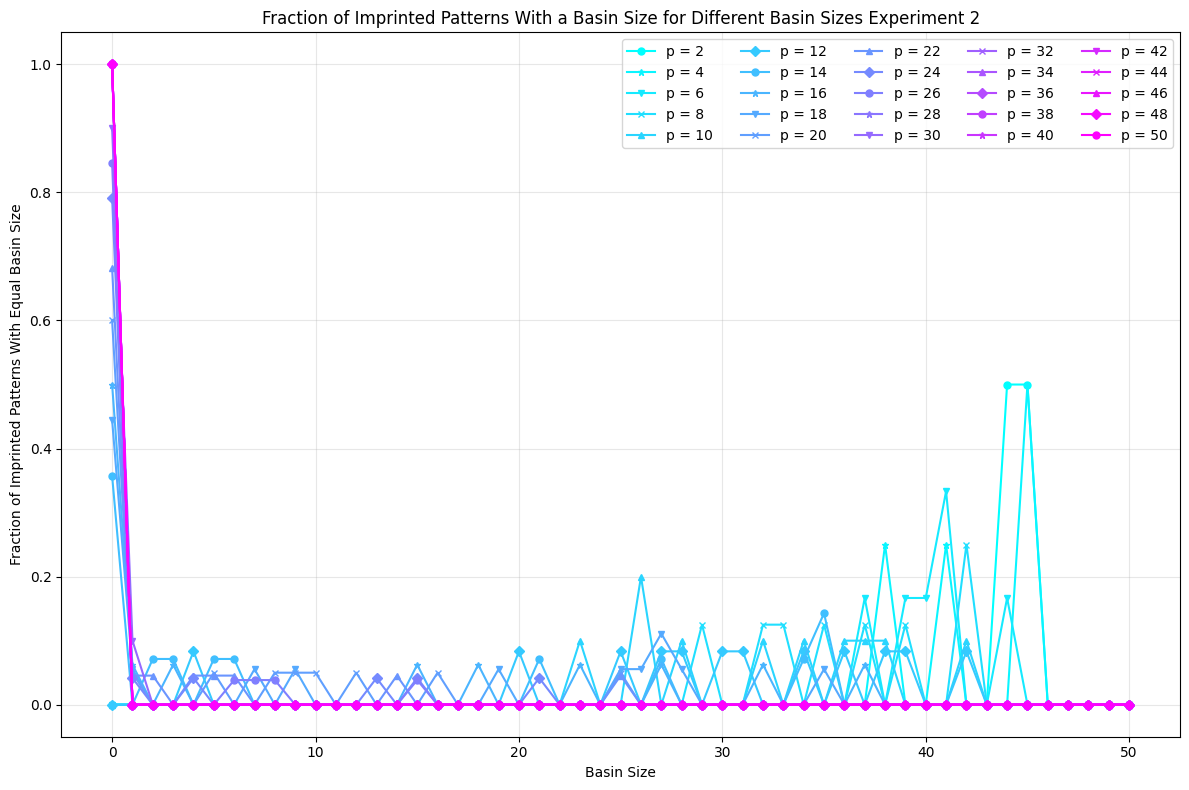

In [99]:
basin_histograms[1]

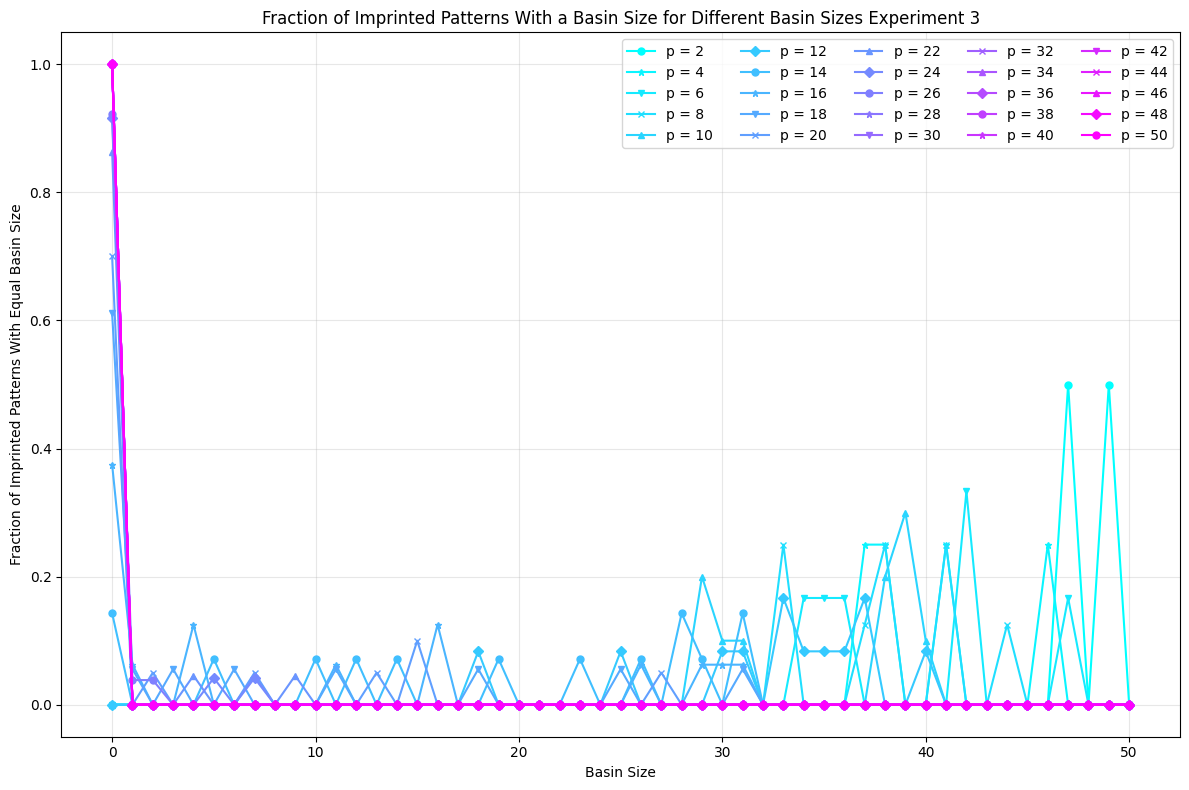

In [100]:
basin_histograms[2]

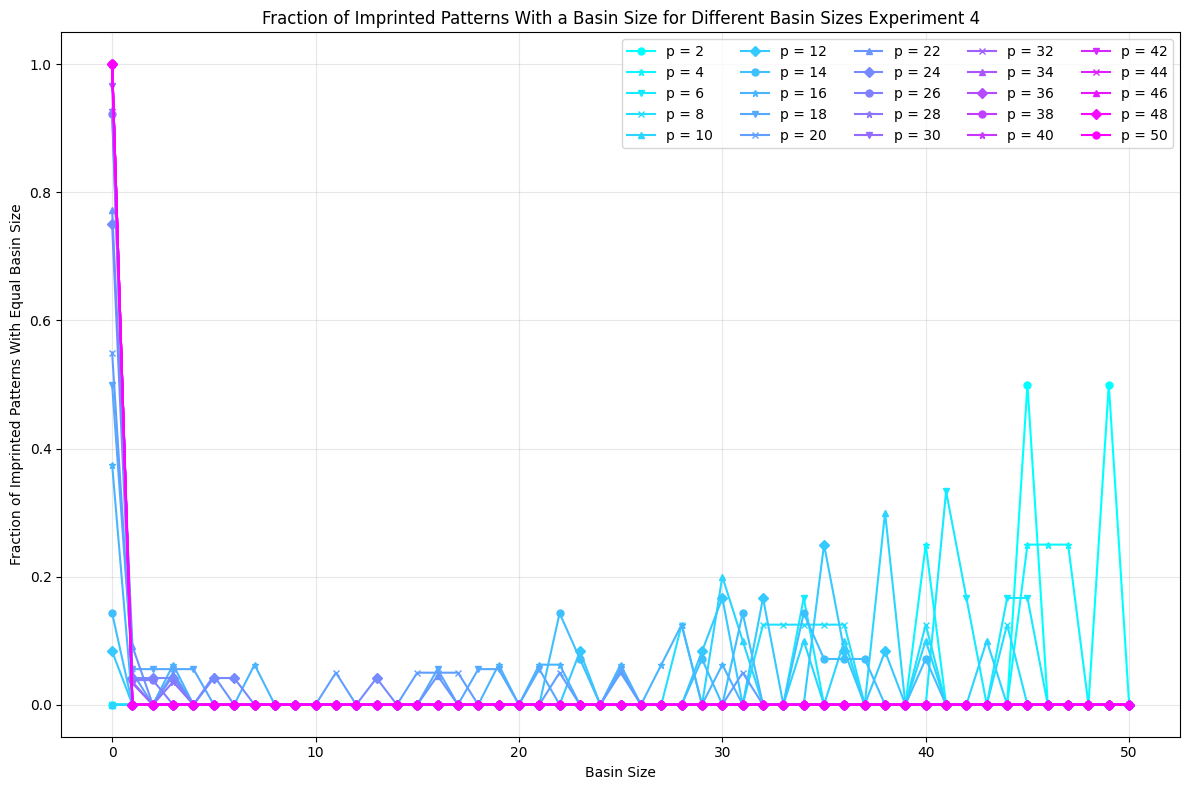

In [101]:
basin_histograms[3]

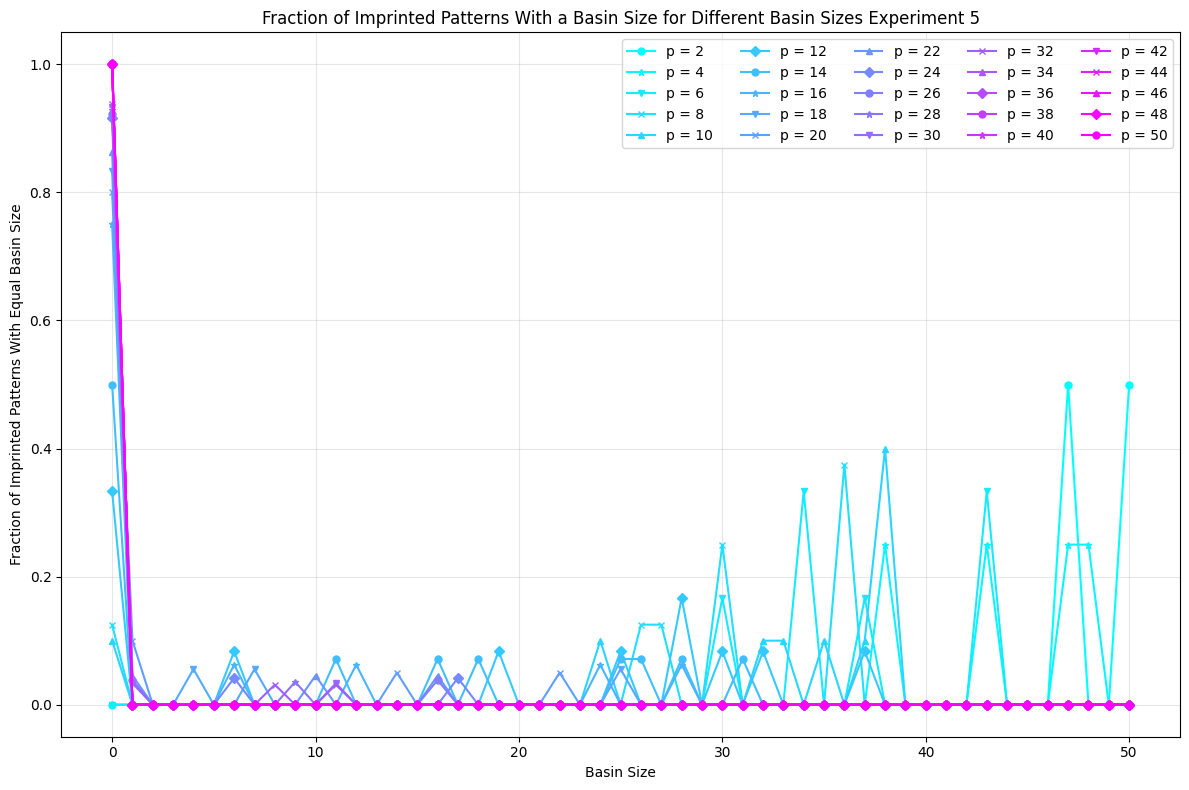

In [102]:
basin_histograms[4]